In [4]:
import numpy as np
import torch
import pandas as pd
import os
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### Variáveis de Ambiente e Configuração de Caminhos
___________

**O que esta célula faz:**
Define os caminhos dos arquivos de dados (treino/teste), os arquivos de *embeddings* pré-processados e o modelo pré-treinado do BERT que será utilizado no projeto.

**O que você precisa fazer para funcionar:**
1. **Fazer o upload dos arquivos:** Certifique-se de enviar os seus arquivos CSV para o ambiente (ex: Google Colab) ou salvar no seu repositório local.
2. **Atualizar os caminhos:** Substitua as strings nos caminhos abaixo pelos caminhos reais onde seus arquivos estão salvos no seu computador ou no servidor:
   * `DATA_PATH`: Caminho do seu arquivo CSV de treino/geral.
   * `DATA_PATH_TEST`: Caminho do seu arquivo CSV de teste.
   * `MODEL_NAME`: Nome do modelo HuggingFace (padrão: BERTimbau).
   * `DATA_EMBEDDINGS_PATH`: Onde salvar/carregar os embeddings de treino gerados pelo BERT.
   * `DATA_EMBEDDINGS_TEST`: Onde salvar/carregar os embeddings de teste gerados pelo BERT.

In [5]:
DATA_PATH = '../training_data/dataset.csv'
DATA_PATH_TEST = '../training_data/teste.csv'
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
DATA_EMBEDDINGS_PATH = 'data_bert.npz'
DATA_EMBEDDINGS_TEST = 'data_bert_test.npz'

### Processamento e Extração de Embeddings com BERT
___
**O que esta célula faz:**
1. **Carregamento e Configuração:** Lê o arquivo CSV de entrada, carrega o modelo BERT pré-treinado e configura o dispositivo de execução (GPU ou CPU).
2. **Divisão de Textos (Chunking):** A função `chunk_text_by_tokens` divide textos longos que ultrapassam o limite do BERT (128 tokens) em pedaços menores com sobreposição (*overlap*).
3. **Extração de Vetores:** Gera o vetor numérico (*embedding* do token `[CLS]`) para cada fragmento e calcula a média deles (`np.mean`), resultando em uma representação única por documento.
4. **Exportação dos Resultados:** Compacta e salva os vetores $X$ e os rótulos $y$ no arquivo binário `data_bert_test.npz`.

**O que fazer para funcionar:**
* Certifique-se de ter executado as células anteriores que carregam as bibliotecas (`pandas`, `numpy`, `torch`, `transformers`) e definem as variáveis de ambiente (`DATA_PATH`, `MODEL_NAME`).
* **Dica de Desempenho:** Se estiver no Google Colab, ative a GPU em *Ambiente de execução -> Alterar o tipo de ambiente de execução -> GPU* para acelerar o processamento do BERT.

In [7]:
df = pd.read_csv(DATA_PATH)
sentences = df["text"].astype(str).tolist()
labels = df["label"].values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = MODEL_NAME
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)


def chunk_text_by_tokens(text, max_tokens=128, overlap=20):
    tokens = tokenizer.encode(text, add_special_tokens=False)

    if len(tokens) <= max_tokens:
        return [text]

    chunks = []
    stride = max_tokens - overlap
    for i in range(0, len(tokens), stride):
        chunk_tokens = tokens[i : i + max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)

    return chunks


def extract_bert_embeddings_with_chunks(
    text_list, max_length=512, batch_size=32
):
    bert_model.eval()
    document_embeddings = []

    with torch.no_grad():
        for text in text_list:
            text_chunks = chunk_text_by_tokens(
                text, max_tokens=max_length - 2, overlap=20
            )

            chunk_vectors = []
            for i in range(0, len(text_chunks), batch_size):
                batch_chunks = text_chunks[i : i + batch_size]
                inputs = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                ).to(device)

                outputs = bert_model(**inputs)
                cls_embeddings = (
                    outputs.last_hidden_state[:, 0, :].cpu().numpy()
                )
                chunk_vectors.append(cls_embeddings)

            all_chunks_matrix = np.vstack(chunk_vectors)
            doc_vector = np.mean(all_chunks_matrix, axis=0)
            document_embeddings.append(doc_vector)

    return np.array(document_embeddings)

X = extract_bert_embeddings_with_chunks(sentences)
y = np.array(labels)

np.savez_compressed("data_bert_test.npz", embeddings=X, labels=y)

print("Arquivo 'data_bert_test.npz' salvo com sucesso!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11586.31it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

### Carregamento dos Embeddings, Divisão de Dados e Configuração dos Modelos
_____

**O que esta célula faz:**
1. **Carregamento dos Vetores:** Verifica se o arquivo `.npz` gerado anteriormente existe e carrega as matrizes de *embeddings* ($X$) e rótulos ($y$).
2. **Divisão Treino/Teste:** Separa 20% dos dados para teste usando amostragem estratificada (`stratify=y`), garantindo que a proporção das classes se mantenha idêntica em ambos os conjuntos.
3. **Definição dos Algoritmos:** Cria um dicionário com 5 classificadores clássicos de Machine Learning (Regressão Logística, Random Forest, SVM, XGBoost e LightGBM).
4. **Configuração da Validação Cruzada:** Define as métricas de avaliação e a estratégia de *K-Fold Stratified* (3 dobras) para os testes.

**O que fazer para funcionar:**
* Certifique-se de que a célula anterior foi executada e o arquivo salvo na variável `DATA_EMBEDDINGS_PATH` realmente existe.
* Garanta a importação do `os`, `numpy` e dos algoritmos do `scikit-learn`, `xgboost` e `lightgbm`.
* Caso veja o aviso de arquivo não encontrado, volte e rode a célula de geração dos embeddings primeiro.

In [8]:
if os.path.exists(DATA_EMBEDDINGS_PATH):
    data = np.load(DATA_EMBEDDINGS_PATH)
    X = data["embeddings"]
    y = data["labels"]
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_PATH}' não encontrado. rode a cédula anterior para carregar os dados")

Arquivo 'data_bert.npz' não encontrado. rode a cédula anterior para carregar os dados


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

trained_models = {}

### Validação Cruzada e Treinamento dos Modelos
_______

**O que esta célula faz:**
1. **Validação Cruzada (Cross-Validation):** Itera sobre cada classificador definido no dicionário e executa a validação cruzada (`cross_validate`) nos dados de treino utilizando as 3 dobras (*folds*) configuradas.
2. **Exibição de Métricas:** Imprime a média das métricas (Acurácia, F1-Score, Precisão e Revocação ponderadas) obtidas nas dobras de validação para avaliar o desempenho geral do algoritmo antes do teste final.
3. **Treinamento Final e Armazenamento:** Re-treina cada modelo com **todo o conjunto de treino** (`X_train` e `y_train`) e salva o modelo ajustado no dicionário `trained_models` para uso posterior.

**O que fazer para funcionar:**
* Certifique-se de ter executado a célula anterior onde as variáveis `classifiers`, `X_train`, `y_train`, `cv` e `scoring` foram definidas.
* Garanta que a função `cross_validate` da biblioteca `sklearn.model_selection` esteja devidamente importada no seu notebook.

In [ ]:
for name, clf in classifiers.items():
    scores = cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring)

    print(f"=== {name} (Validação Cruzada - Treino) ===")
    print(f"Acurácia Média: {scores['test_accuracy'].mean():.4f}")
    print(f"F1-Score Médio: {scores['test_f1_weighted'].mean():.4f}")
    print(f"Precisão Média: {scores['test_precision_weighted'].mean():.4f}")
    print(f"Revocação Média: {scores['test_recall_weighted'].mean():.4f}\n")

    clf.fit(X_train, y_train)
    trained_models[name] = clf

=== Logistic Regression (Validação Cruzada - Treino) ===
Acurácia Média: 0.9893
F1-Score Médio: 0.9893
Precisão Média: 0.9893
Revocação Média: 0.9893

=== Random Forest (Validação Cruzada - Treino) ===
Acurácia Média: 0.9601
F1-Score Médio: 0.9601
Precisão Média: 0.9602
Revocação Média: 0.9601

=== SVM (RBF) (Validação Cruzada - Treino) ===
Acurácia Média: 0.9820
F1-Score Médio: 0.9820
Precisão Média: 0.9820
Revocação Média: 0.9820

=== XGBoost (Validação Cruzada - Treino) ===
Acurácia Média: 0.9801
F1-Score Médio: 0.9801
Precisão Média: 0.9801
Revocação Média: 0.9801



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== LightGBM (Validação Cruzada - Treino) ===
Acurácia Média: 0.9767
F1-Score Médio: 0.9767
Precisão Média: 0.9767
Revocação Média: 0.9767



### Função de Avaliação, Geração da Matriz de Confusão e Registro de Histórico
________

**O que esta célula faz:**
1. **Criação do Histórico:** Inicializa a lista global `results` para armazenar as métricas calculadas em cada teste.
2. **Avaliação do Modelo:** Define a função `test_and_save` que realiza as predições (`predict`) para um conjunto de dados e calcula as métricas binárias: Acurácia, F1-Score, Precisão e Revocação (Recall).
3. **Extração da Matriz de Confusão:** Calcula a matriz de confusão e descompacta os valores de **Verdadeiro Negativo (TN)**, **Falso Positivo (FP)**, **Falso Negativo (FN)** e **Verdadeiro Positivo (TP)**.
4. **Armazenamento Estruturado:** Adiciona um dicionário na lista `results` contendo a data/hora da execução, nome do modelo, nome do conjunto (ex: treino/teste), métricas e a matriz detalhada (ideal para conversão futura em DataFrame).
5. **Exibição de Resultados:** Imprime as métricas e o formato em matriz no console para rápida visualização.

**O que fazer para funcionar:**
* Certifique-se de ter importado a biblioteca `datetime` e os módulos de avaliação do Scikit-Learn: `accuracy_score`, `f1_score`, `precision_score`, `recall_score` e `confusion_matrix`.
* Execute esta célula antes de rodar os testes finais nos dados de avaliação/teste.

In [ ]:
results = []

def test_and_save(model_name, clf, x_eval, y_eval, set_name):
    try:
        y_pred = clf.predict(x_eval)

        acc = accuracy_score(y_eval, y_pred)
        f1 = f1_score(y_eval, y_pred, average='binary')
        prec = precision_score(y_eval, y_pred, average='binary')
        rec = recall_score(y_eval, y_pred, average='binary')

        cm = confusion_matrix(y_eval, y_pred)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = fp = fn = tp = None

        results.append({
            'Exe_date': datetime.datetime.now().strftime("%d-%m-%Y %H:%M:%S"),
            'Model': model_name,
            'Set': set_name,
            'Accuracy': acc,
            'F1-Score': f1,
            'Precision': prec,
            'Recall': rec,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Confusion_Matrix': cm.tolist()
        })

        print(f"[{set_name}] [{model_name}] -> Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
        print("Matriz de Confusão:")
        print(cm)
        print("-" * 50)

    except Exception as e:
        print(f"!!! Erro ao avaliar o modelo {model_name}: {e} !!!")

### Execução dos Testes nos Conjuntos Interno e Externo
________

**O que esta célula faz:**
1. **Avaliação no Teste Interno:** Itera sobre os modelos treinados (`trained_models`) e aplica a função `test_and_save` no conjunto de validação separado do treino (`X_test`, `y_test`), rotulando como "Teste Interno".
2. **Carregamento dos Dados Externos:** Verifica a existência do arquivo definido em `DATA_EMBEDDINGS_TEST` e carrega os novos vetores e rótulos de teste.
3. **Avaliação no Teste Externo:** Caso o arquivo exista, avalia todos os modelos nesse novo conjunto de dados inédito ("Teste Externo"), permitindo comparar a capacidade de generalização dos algoritmos.
4. **Tratamento de Exceção:** Exibe uma mensagem de aviso caso o arquivo de teste externo não seja localizado no caminho especificado.

**O que fazer para funcionar:**
* Certifique-se de que a função `test_and_save` e o dicionário `trained_models` foram executados nas células anteriores.
* Garanta que as bibliotecas `os` e `numpy` estejam importadas.
* Verifique se o arquivo indicado na variável `DATA_EMBEDDINGS_TEST` foi gerado e salvo corretamente no ambiente.

In [ ]:
for name, clf in trained_models.items():
  test_and_save(name, clf, X_test, y_test, "Teste Interno")

[Teste Interno] [Logistic Regression] -> Acc: 0.9894 | F1: 0.9894 | Prec: 0.9893 | Rec: 0.9895
Matriz de Confusão:
[[4523   49]
 [  48 4532]]
--------------------------------------------------
[Teste Interno] [Random Forest] -> Acc: 0.9646 | F1: 0.9645 | Prec: 0.9691 | Rec: 0.9598
Matriz de Confusão:
[[4432  140]
 [ 184 4396]]
--------------------------------------------------
[Teste Interno] [SVM (RBF)] -> Acc: 0.9836 | F1: 0.9836 | Prec: 0.9868 | Rec: 0.9803
Matriz de Confusão:
[[4512   60]
 [  90 4490]]
--------------------------------------------------
[Teste Interno] [XGBoost] -> Acc: 0.9830 | F1: 0.9830 | Prec: 0.9836 | Rec: 0.9823
Matriz de Confusão:
[[4497   75]
 [  81 4499]]
--------------------------------------------------
[Teste Interno] [LightGBM] -> Acc: 0.9802 | F1: 0.9802 | Prec: 0.9818 | Rec: 0.9786
Matriz de Confusão:
[[4489   83]
 [  98 4482]]
--------------------------------------------------


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
if os.path.exists(DATA_EMBEDDINGS_TEST):
    data = np.load(DATA_EMBEDDINGS_TEST)
    X = data["embeddings"]
    y = data["labels"]

    for name, clf in trained_models.items():
      test_and_save(name, clf, X, y, "Teste Externo")
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_TEST}' não encontrado.")

[Teste Externo] [Logistic Regression] -> Acc: 0.9937 | F1: 0.9935 | Prec: 0.9946 | Rec: 0.9924
Matriz de Confusão:
[[2329   12]
 [  17 2218]]
--------------------------------------------------
[Teste Externo] [Random Forest] -> Acc: 0.9924 | F1: 0.9921 | Prec: 0.9950 | Rec: 0.9893
Matriz de Confusão:
[[2330   11]
 [  24 2211]]
--------------------------------------------------
[Teste Externo] [SVM (RBF)] -> Acc: 0.9862 | F1: 0.9858 | Prec: 0.9901 | Rec: 0.9817
Matriz de Confusão:
[[2319   22]
 [  41 2194]]
--------------------------------------------------
[Teste Externo] [XGBoost] -> Acc: 0.9965 | F1: 0.9964 | Prec: 0.9978 | Rec: 0.9951
Matriz de Confusão:
[[2336    5]
 [  11 2224]]
--------------------------------------------------
[Teste Externo] [LightGBM] -> Acc: 0.9941 | F1: 0.9939 | Prec: 0.9964 | Rec: 0.9915
Matriz de Confusão:
[[2333    8]
 [  19 2216]]
--------------------------------------------------


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Consolidação dos Resultados, Exportação em CSV e Visualização Gráfica
___

**O que esta célula faz:**
1. **Exportação de Dados:** Converte a lista `results` em um DataFrame do Pandas e salva um arquivo `.csv` codificado com a data e hora atual.
2. **Gráfico de Desempenho:** Gera um gráfico de barras comparando as métricas (**Accuracy**, **F1-Score**, **Precision** e **Recall**) de cada algoritmo.
3. **Matrizes de Confusão:** Exibe um painel (*grid*) com as matrizes de confusão visuais (Heatmaps) para cada modelo avaliado.

**O que fazer para funcionar:**
* Garanta que as bibliotecas `matplotlib` e `seaborn` estejam instaladas e importadas (`import matplotlib.pyplot as plt`, `import seaborn as sns`).
* Certifique-se de ter executado a etapa anterior que preenche a lista `results`.

/tmp/ipykernel_3943/1356962014.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  chart = sns.barplot(


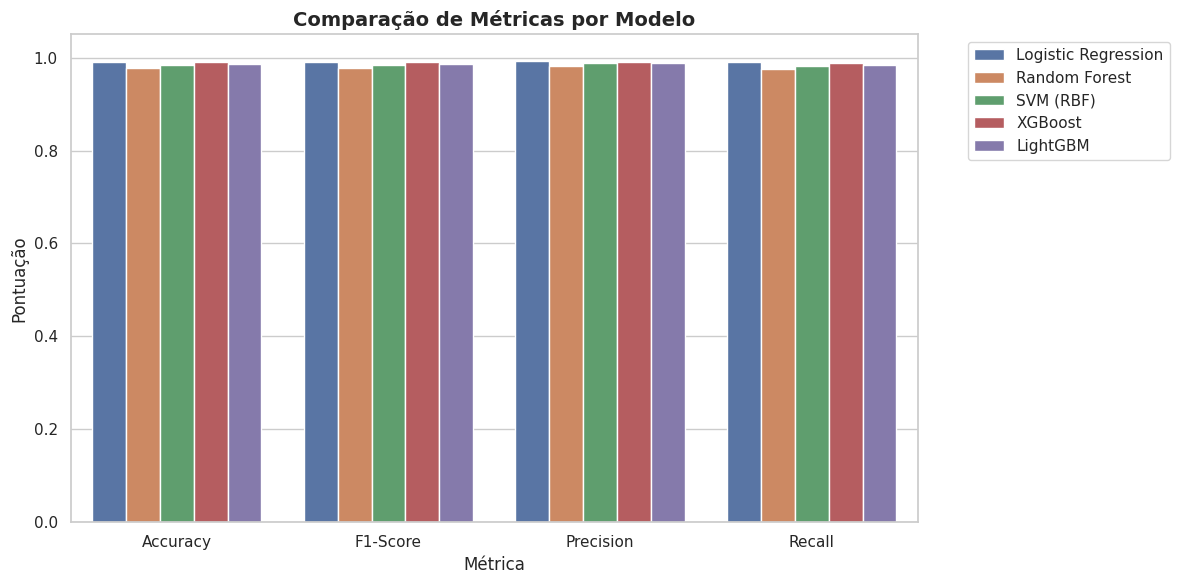

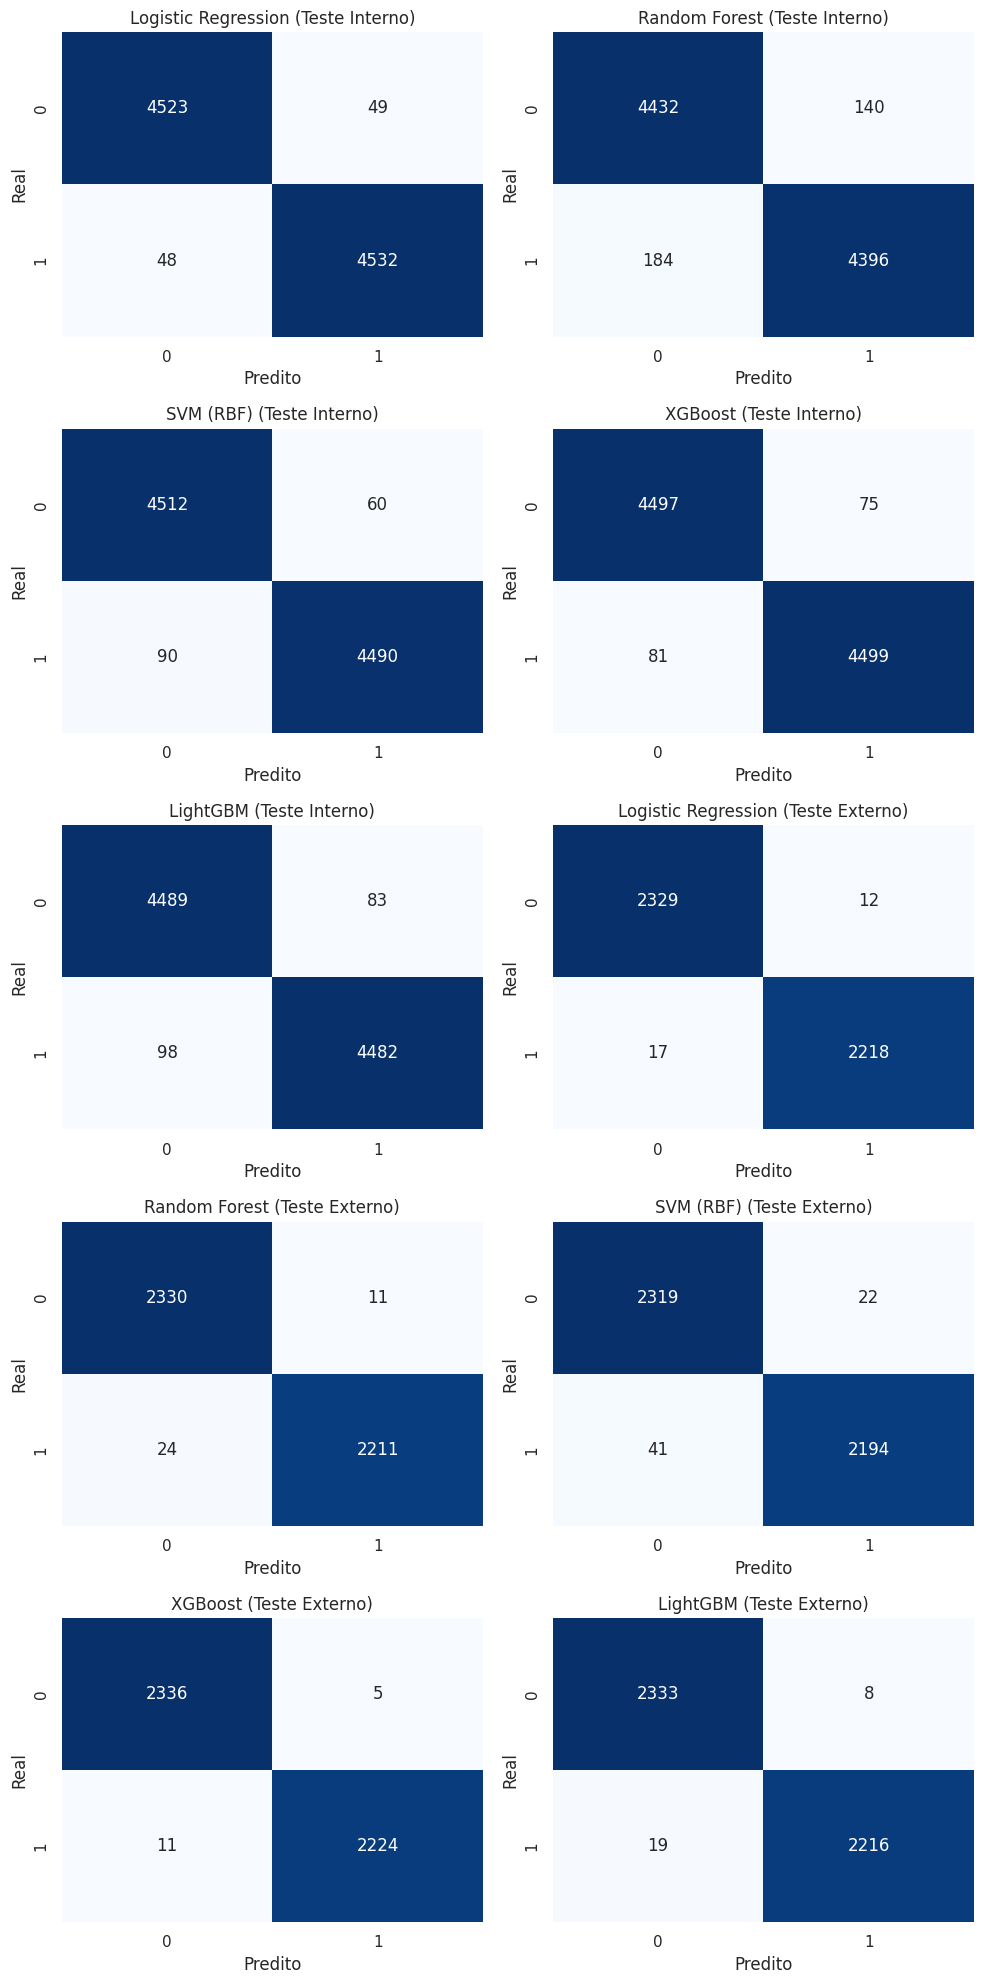

In [ ]:
df_result = pd.DataFrame(results)
date = datetime.datetime.now().strftime("%d-%m-%Y_%H-%M-%S")
df_result.to_csv(f'/content/drive/MyDrive/Colab Notebooks/Residencia IA Eldorado/Testes ML - Stroj/results_{date}.csv', index=False)

sns.set_theme(style="whitegrid")

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
df_melted = df_result.melt(
    id_vars=['Model', 'Set'],
    value_vars=metrics,
    var_name='Métrica',
    value_name='Pontuação'
)

plt.figure(figsize=(12, 6))
chart = sns.barplot(
    data=df_melted,
    x='Métrica',
    y='Pontuação',
    hue='Model',
    ci=None
)
plt.title('Comparação de Métricas por Modelo', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

num_models = len(df_result)
cols = 2
rows = (num_models + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows))
axes = axes.flatten() if num_models > 1 else [axes]

for idx, row in df_result.iterrows():
    ax = axes[idx]
    cm = np.array(row['Confusion_Matrix'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{row['Model']} ({row['Set']})")
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()